In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os 
import glob
import math

In [277]:
class Test:
    def __init__(self, df):
        self.df = df
        self.id = df['participant_ID'][0]
        self.date = df['visit_date'][0]
        self.name = f"{self.id}_{self.date}"
        self.df['Stage'] = self.df[self.df['Phase'] == 'EXERCISE'].groupby(['Speed','Grade']).ngroup() + 1

        self.df = self.df.set_index('t', drop=False)
        #max_stage = self.df['Stage'].max()
        #self.df.loc[self.df['Phase'] == 'WARMUP', 'Stage'] = 0
        #self.df.loc[self.df['Phase'] == 'RECOVERY', 'Stage'] = max_stage + 1
        self.lactate_df = self.df.dropna(subset='La-')[['La-', 'Phase', 't', 'Speed', 'Grade', 'Stage']] 
        self.lactate_df = self.lactate_df.drop(self.lactate_df[self.lactate_df['La-'] > 20].index)
        self.lactate_df['log_lactate'] = np.log(self.lactate_df['La-'])
        self.lactate_df['log_speed'] = np.log(self.lactate_df['Speed'])

    """def lactate_graph(self):
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # Reference mode
        axes[0].plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o')
        axes[0].set_xlabel('Time')
        axes[0].set_ylabel('Lactate')
        axes[0].set_title('Lactate vs Time Using Reference ' + self.name)
        axes[0].set_ylim(0, None)
        LT1_ref, LT2_ref, LT1_idx_ref, LT2_idx_ref = self.lt_ref_vals()
        if LT1_ref:
            axes[0].axvline(x=LT1_ref, color='r', label='LT1')
        if LT2_ref:
            axes[0].axvline(x=LT2_ref, color='g', linestyle='--', label='LT2')
        ax2_ref = axes[0].twinx()
        axes[0].legend()
        
        # Absolute mode
        axes[1].plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o')
        axes[1].set_xlabel('Time')
        axes[1].set_ylabel('Lactate')
        axes[1].set_title('Lactate vs Time Using Absolute ' + self.name)
        axes[1].set_ylim(0, None)
        LT1_abs, LT2_abs, LT1_idx_abs, LT2_idx_abs = self.lt_abs_vals()
        axes[1].axhline(y=2, color='r', label='Threshold 2 mmol/L')
        axes[1].axhline(y=4, color='g', linestyle='--', label='Threshold 4 mmol/L')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Extract and return LT1 and LT2 data
        results = {
        'LT1_Lactate_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'La-'] if LT1_ref else None,
        'LT1_Speed_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'Speed'] if LT1_ref else None,
        'LT1_Grade_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'Grade'] if LT1_ref else None,
        'LT2_Lactate_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'La-'] if LT2_ref else None,
        'LT2_Speed_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'Speed'] if LT2_ref else None,
        'LT2_Grade_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'Grade'] if LT2_ref else None,
        'LT1_Lactate_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'La-'] if LT1_abs else None,
        'LT1_Speed_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'Speed'] if LT1_abs else None,
        'LT1_Grade_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'Grade'] if LT1_abs else None,
        'LT2_Lactate_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'La-'] if LT2_abs else None,
        'LT2_Speed_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'Speed'] if LT2_abs else None,
        'LT2_Grade_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'Grade'] if LT2_abs else None
        }
        return results"""
    def lactate_graph(self):
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # Reference mode
        axes[0].plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o', label='Lactate')
        axes[0].set_xlabel('Time')
        axes[0].set_ylabel('Lactate mmol/L')
        axes[0].set_title('Lactate vs Time Using Reference ' + self.name)
        axes[0].set_ylim(0, None)
        LT1_ref, LT2_ref, LT1_idx_ref, LT2_idx_ref = self.lt_ref_vals()
        if LT1_ref:
            axes[0].axvline(x=LT1_ref, color='r', label='LT1')
        if LT2_ref:
            axes[0].axvline(x=LT2_ref, color='g', linestyle='--', label='LT2')
        '''
        # Create a twin axis for speed using df's speed data
        ax2_ref = axes[0].twinx()
        
        # Plot speed from df on the twin axis using lactate_df's times as the x-axis
        ax2_ref.plot(self.lactate_df['t'], self.df.loc[self.df['t'].isin(self.lactate_df['t']), 'Speed'], color='black', label='Speed', alpha=0.2)
        ax2_ref.set_ylabel('Speed mph', color='black', alpha=0.5)
        ax2_ref.tick_params(axis='y', labelcolor='black')
        '''
        # Reduce the number of x-ticks to only those where lactate measurements exist
        axes[0].set_xticks(self.lactate_df['t'])  # Set ticks only where lactate is measured
        
        axes[0].legend(loc='upper left')
        #ax2_ref.legend(loc='upper right')
        
        # Absolute mode
        axes[1].plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o', label='Lactate')
        axes[1].set_xlabel('Time')
        axes[1].set_ylabel('Lactate mmol/L')
        axes[1].set_title('Lactate vs Time Using Absolute ' + self.name)
        axes[1].set_ylim(0, None)
        LT1_abs, LT2_abs, LT1_idx_abs, LT2_idx_abs = self.lt_abs_vals()
        axes[1].axhline(y=2, color='r', label='Threshold 2 mmol/L')
        axes[1].axhline(y=4, color='g', linestyle='--', label='Threshold 4 mmol/L')
        '''
        # Create a twin axis for speed
        ax2_abs = axes[1].twinx()
        
        # Plot speed from df on the twin axis using lactate_df's times as the x-axis
        ax2_abs.plot(self.lactate_df['t'], self.df.loc[self.df['t'].isin(self.lactate_df['t']), 'Speed'], color='black', label='Speed', alpha=0.2)
        ax2_abs.set_ylabel('Speed mph', color='black', alpha=0.5)
        ax2_abs.tick_params(axis='y', labelcolor='black')
        '''
        # Reduce the number of x-ticks to only those where lactate measurements exist
        axes[1].set_xticks(self.lactate_df['t'])  # Set ticks only where lactate is measured
        
        axes[1].legend(loc='upper left')
        #ax2_abs.legend(loc='upper right')
        
        plt.tight_layout()
        #plt.show()
        
        # Extract and return LT1 and LT2 data
        results = {
        'LT1_Lactate_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'La-'] if LT1_ref else None,
        'LT1_Speed_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'Speed'] if LT1_ref else None,
        'LT1_Grade_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'Grade'] if LT1_ref else None,
        'LT2_Lactate_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'La-'] if LT2_ref else None,
        'LT2_Speed_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'Speed'] if LT2_ref else None,
        'LT2_Grade_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'Grade'] if LT2_ref else None,
        'LT1_Lactate_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'La-'] if LT1_abs else None,
        'LT1_Speed_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'Speed'] if LT1_abs else None,
        'LT1_Grade_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'Grade'] if LT1_abs else None,
        'LT2_Lactate_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'La-'] if LT2_abs else None,
        'LT2_Speed_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'Speed'] if LT2_abs else None,
        'LT2_Grade_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'Grade'] if LT2_abs else None
        }
        return results

    
    def lt_ref_vals(self):
        lt1ref_index = (self.lactate_df['La-'].diff() >= 0.5)
        lt2ref_index = (self.lactate_df['La-'].diff() >= 1)
        LT1ref = self.lactate_df.loc[lt1ref_index.idxmax(), 't'] if lt1ref_index.any() else None
        LT2ref = self.lactate_df.loc[lt2ref_index.idxmax(), 't'] if lt2ref_index.any() else None
        return LT1ref, LT2ref, lt1ref_index, lt2ref_index
    
    def lt_abs_vals(self):
        lt1ref_index = (self.lactate_df['La-'] >= 2)
        lt2ref_index = (self.lactate_df['La-'] >= 4)
        LT1ref = self.lactate_df.loc[lt1ref_index.idxmax(), 't'] if lt1ref_index.any() else None
        LT2ref = self.lactate_df.loc[lt2ref_index.idxmax(), 't'] if lt2ref_index.any() else None
        return LT1ref, LT2ref, lt1ref_index, lt2ref_index
    
    def heart_rate_graph(self):
        fig, ax1 = plt.subplots(figsize=(10, 5))

        # Calculate the rolling mean of heart rate with a window size of 5 seconds
        exercise_df = self.df[self.df['Phase'] == 'EXERCISE']
        rolling_mean = exercise_df['HR'].rolling(window=2).mean()

        # Plot heart rate on primary y-axis
        ax1.plot(exercise_df['t'], rolling_mean, color='blue', label='Heart Rate')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Heart Rate')
        ax1.set_title('Heart Rate and Speed Over Time')
        ax1.grid(True)

        # Find stage change times
        stage_changes = exercise_df[exercise_df['Stage'] != exercise_df['Stage'].shift()]
        stage_times = stage_changes['t']

        # Plot vertical bars at stage change points
        for time in stage_times:
            ax1.axvline(x=time, color='red', linestyle='--', alpha=0.3)

        # Create twin axis for speed
        ax2 = ax1.twinx()
        ax2.plot(exercise_df['t'], exercise_df['Speed'], color='black', linestyle='-', alpha=0.6, label='Speed')
        ax2.set_ylabel('Speed (mph)', color='black')
        ax2.tick_params(axis='y', labelcolor='black')

        # Set x-axis tick marks only at lactate measurement times
        lactate_times = self.lactate_df['t'][:-3]
        ax1.set_xticks(lactate_times)

        fig.tight_layout()
        plt.show()
    
    def linear_regression(self, x, y):
        """Perform linear regression and return slope, intercept, and r-value."""
        slope, intercept, r_value, _, _ = linregress(x, y)
        return slope, intercept, r_value

    def plot_regression(self, x, y, slope, intercept, xlabel, ylabel, title, color='red', intersection=None):
        """Plot the data and regression line."""
        plt.scatter(x, y, color='black', label='Data')
        plt.plot(x, slope * x + intercept, color=color, linestyle='-', label=f'Linear Fit (r={slope:.2f})')

        if intersection:
            plt.scatter(*intersection, color='blue', zorder=3, label='Intersection')

        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(True)
    
    
    def lt_log_semilog(self):
        """Creates LT1 (log-log) and LT2 (semi-log) plots with two regression lines each."""

        fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        # === LT1: Log Speed vs Log Lactate ===
        filtered_df = self.lactate_df.drop_duplicates(subset='Speed', keep='first')
        filtered_df = filtered_df[filtered_df['Speed'] > 2]

        log_speed = np.log(filtered_df['Speed'])
        log_lactate = np.log(filtered_df['La-'])

        # First 3 and last 4 points for regression
        x_first, y_first = log_speed[:2], log_lactate[:2]
        x_last, y_last = log_speed[-3:], log_lactate[-3:]

        slope_first, intercept_first, _ = self.linear_regression(x_first, y_first)
        slope_last, intercept_last, _ = self.linear_regression(x_last, y_last)

        # Calculate intersection
        x_intersect_lt1 = (intercept_last - intercept_first) / (slope_first - slope_last)
        y_intersect_lt1 = slope_first * x_intersect_lt1 + intercept_first

        # Plot LT1
        axs[0].scatter(log_speed, log_lactate, color='black', label='Data')
        axs[0].plot(log_speed, slope_first * log_speed + intercept_first, 'r-')
        axs[0].plot(log_speed, slope_last * log_speed + intercept_last, 'g-')
        axs[0].scatter(x_intersect_lt1, y_intersect_lt1, color='blue', zorder=3, label='Intersection')
        axs[0].set_xlabel('Log Speed')
        axs[0].set_ylabel('Log Lactate')
        axs[0].set_title('LT1: Log Speed vs Log Lactate')
        axs[0].set_ylim(0, max(log_lactate) * 1.1)  # Ensure y-axis starts at 0
        axs[0].legend()
        axs[0].grid(True)

        # === LT2: Speed vs Log Lactate ===
        speed = filtered_df['Speed']
        log_lactate = np.log(filtered_df['La-'])

        # First 3 and last 4 points for regression
        x_first, y_first = speed[:3], log_lactate[:3]
        x_last, y_last = speed[-3:], log_lactate[-3:]

        slope_first, intercept_first, _ = self.linear_regression(x_first, y_first)
        slope_last, intercept_last, _ = self.linear_regression(x_last, y_last)

        # Calculate intersection
        x_intersect_lt2 = (intercept_last - intercept_first) / (slope_first - slope_last)
        y_intersect_lt2 = slope_first * x_intersect_lt2 + intercept_first

        # Plot LT2
        axs[1].scatter(speed, log_lactate, color='black', label='Data')
        #axs[1].plot(speed, slope_first * speed + intercept_first, 'r-')
        #axs[1].plot(speed, slope_last * speed + intercept_last, 'g-')
        #axs[1].scatter(x_intersect_lt2, y_intersect_lt2, color='blue', zorder=3, label='Intersection')
        axs[1].set_xlabel('Speed')
        axs[1].set_ylabel('Log Lactate')
        axs[1].set_title('LT2: Speed vs Log Lactate')
        axs[1].set_ylim(0, max(log_lactate) * 1.1)  # Ensure y-axis starts at 0
        axs[1].legend()
        axs[1].grid(True)

        plt.tight_layout()
        plt.show()

        print(f"LT1 Intersection: ({x_intersect_lt1:.2f}, {y_intersect_lt1:.2f})")
        print(f"LT1 level: {math.pow(math.e, y_intersect_lt1):.2f}, LT1 speed: {math.pow(math.e, x_intersect_lt1):.2f}")
        print(f"LT2 Intersection: ({x_intersect_lt2:.2f}, {y_intersect_lt2:.2f})")
        print(f"LT2 level: {math.pow(math.e, y_intersect_lt2):.2f}, LT2 speed: {x_intersect_lt2:.2f}")

        return (math.pow(10,x_intersect_lt1), math.pow(10, y_intersect_lt1)), (x_intersect_lt2, math.pow(10,y_intersect_lt2))

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


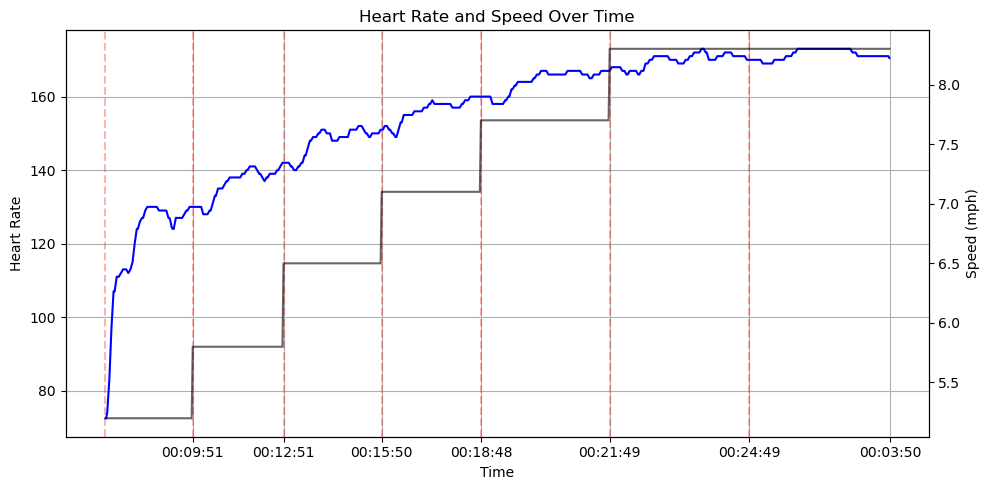

In [278]:
df = pd.read_csv('visit_data/TR000106_20220420_visit_data.csv')
test = Test(df)
test.heart_rate_graph()

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


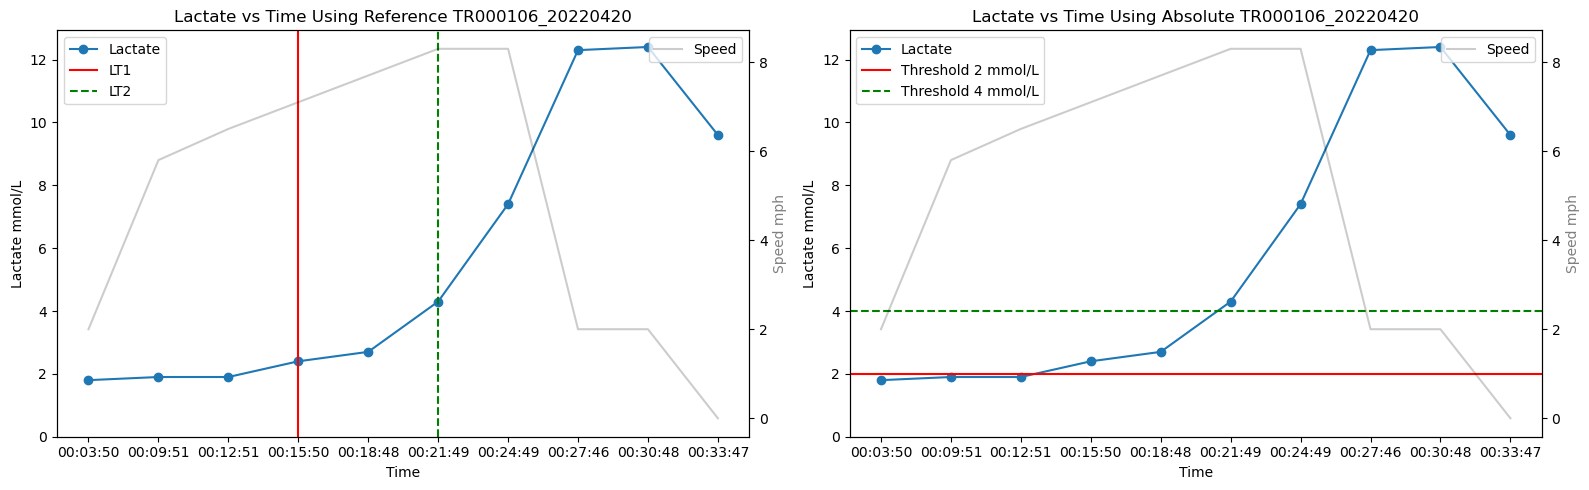

'TR000106_20220420'

In [152]:
df = pd.read_csv('visit_data/TR000106_20220420_visit_data.csv')
test = Test(df)
test.lactate_graph()
test.name

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


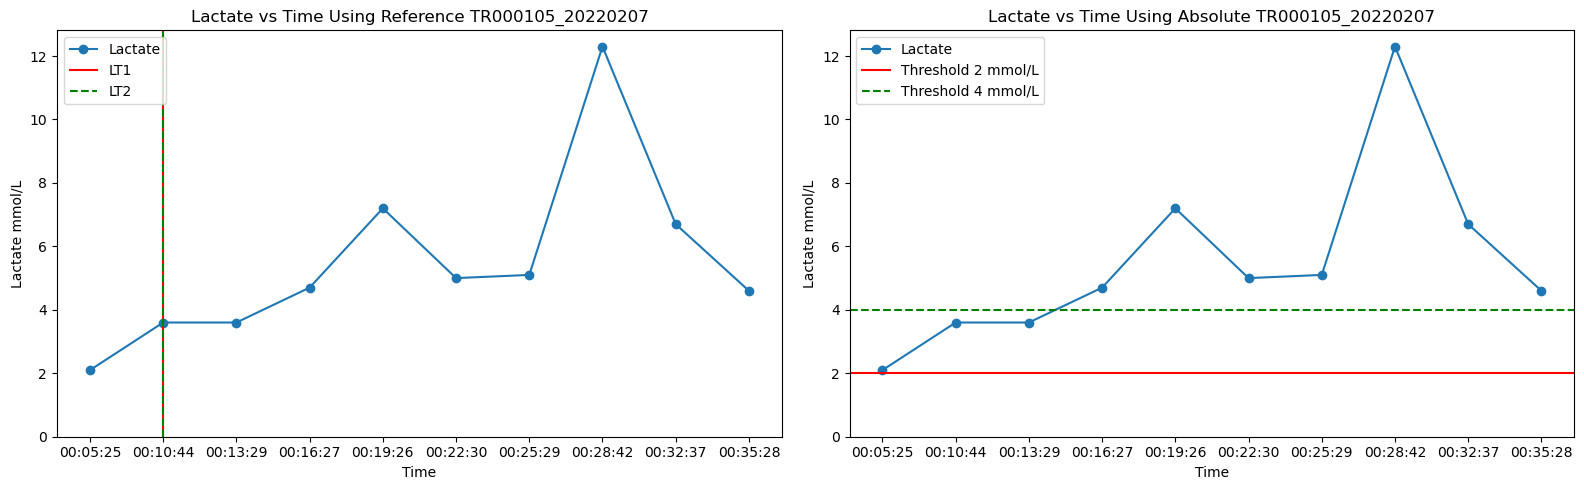

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


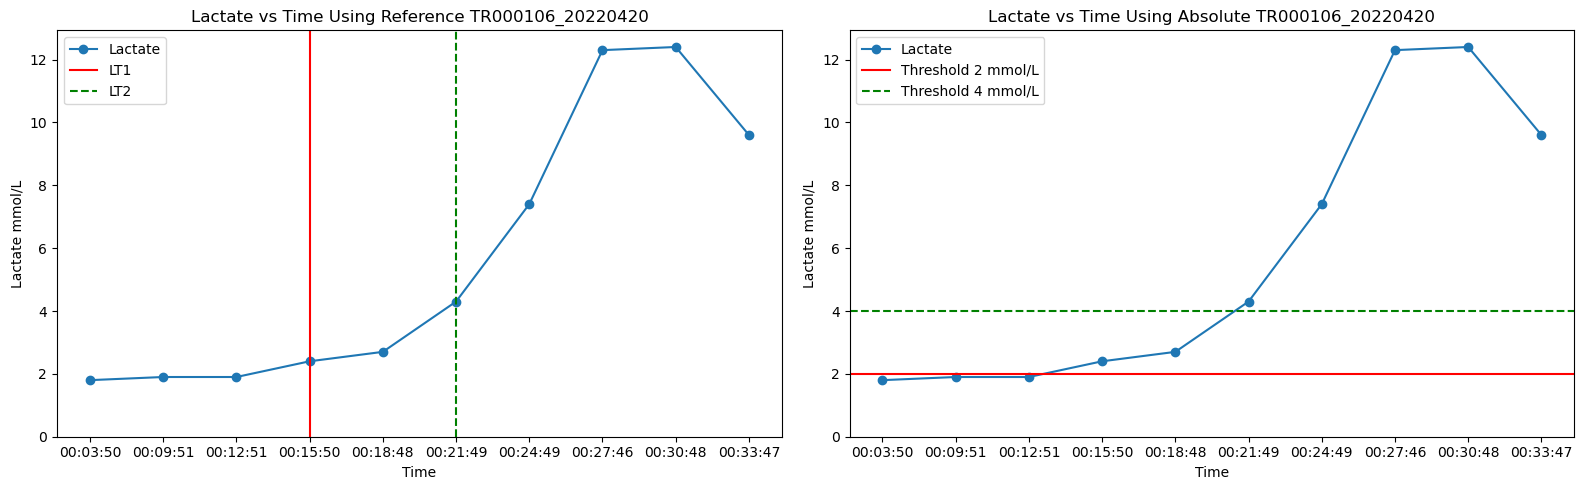

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


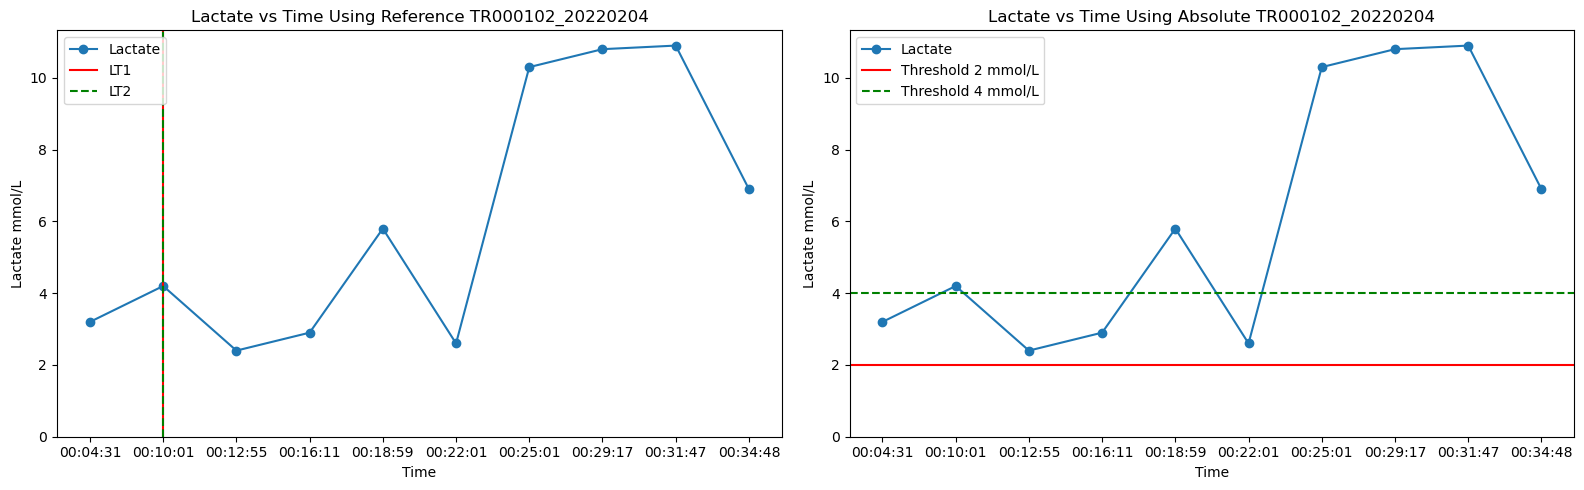

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


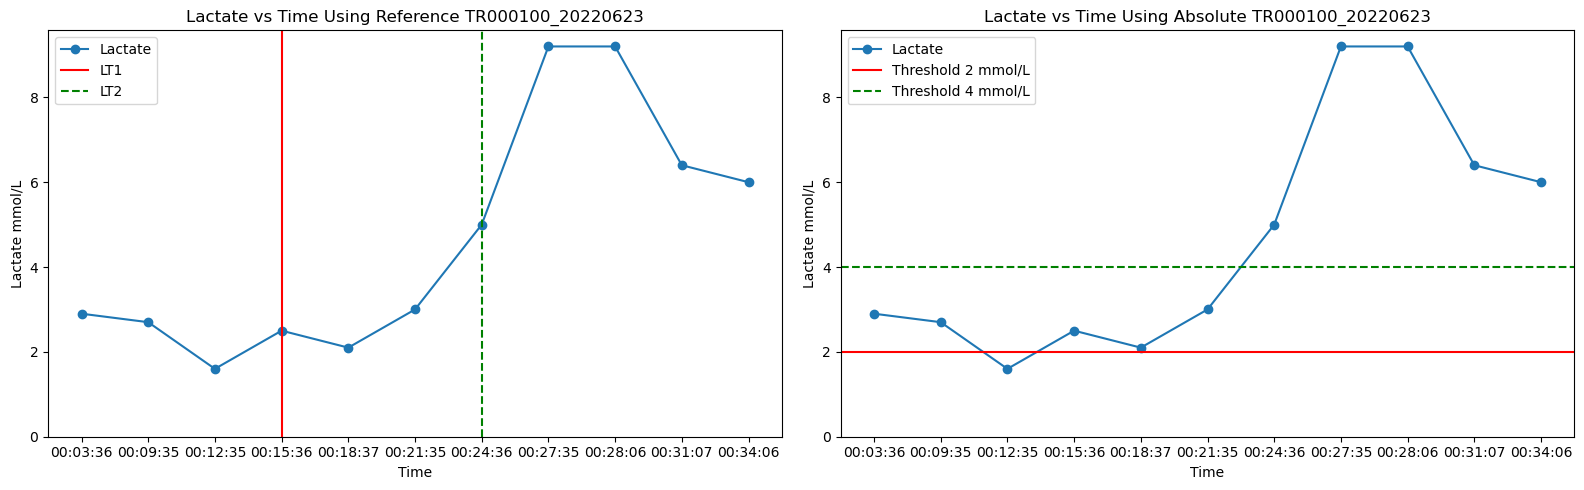

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


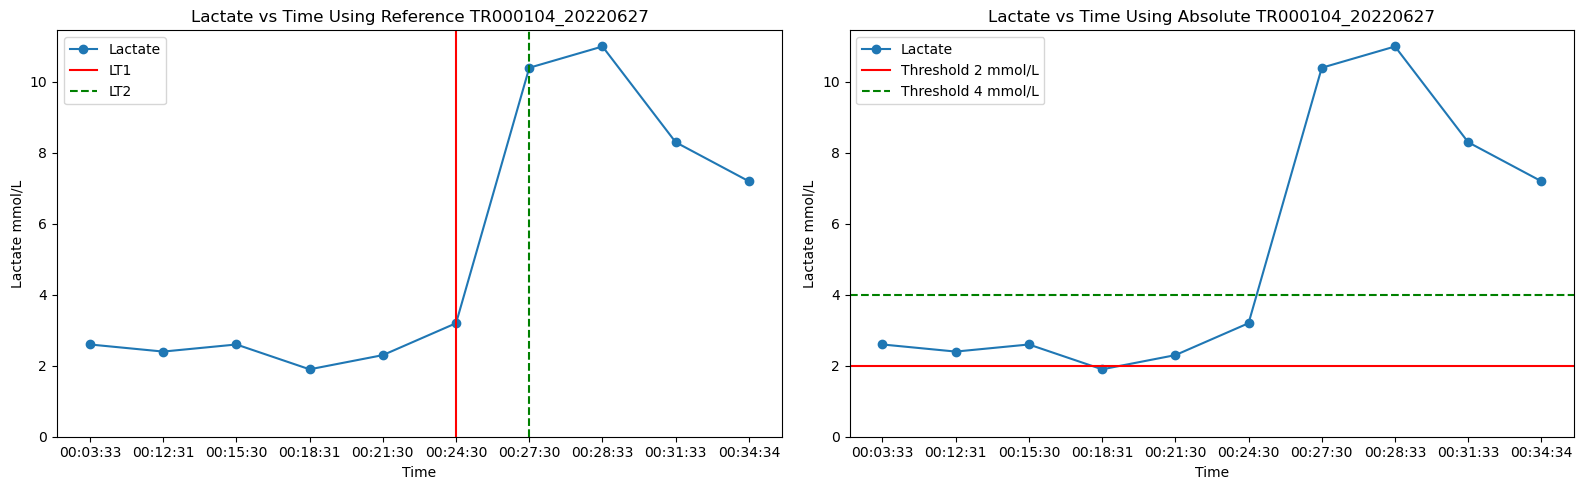

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


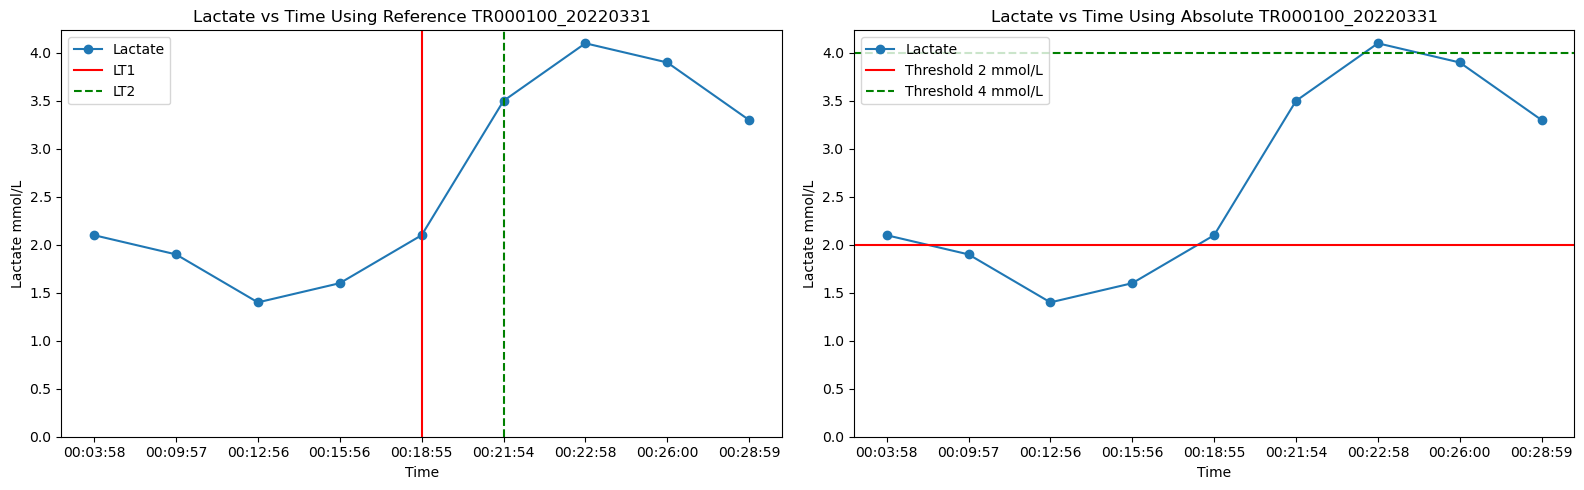

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


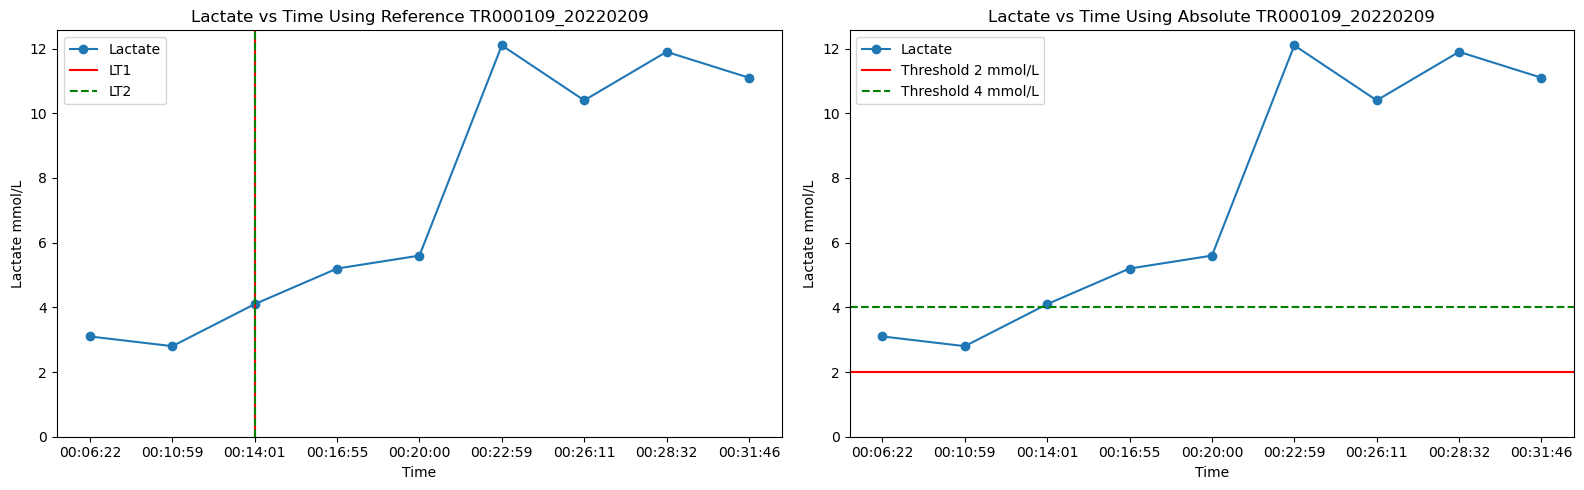

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


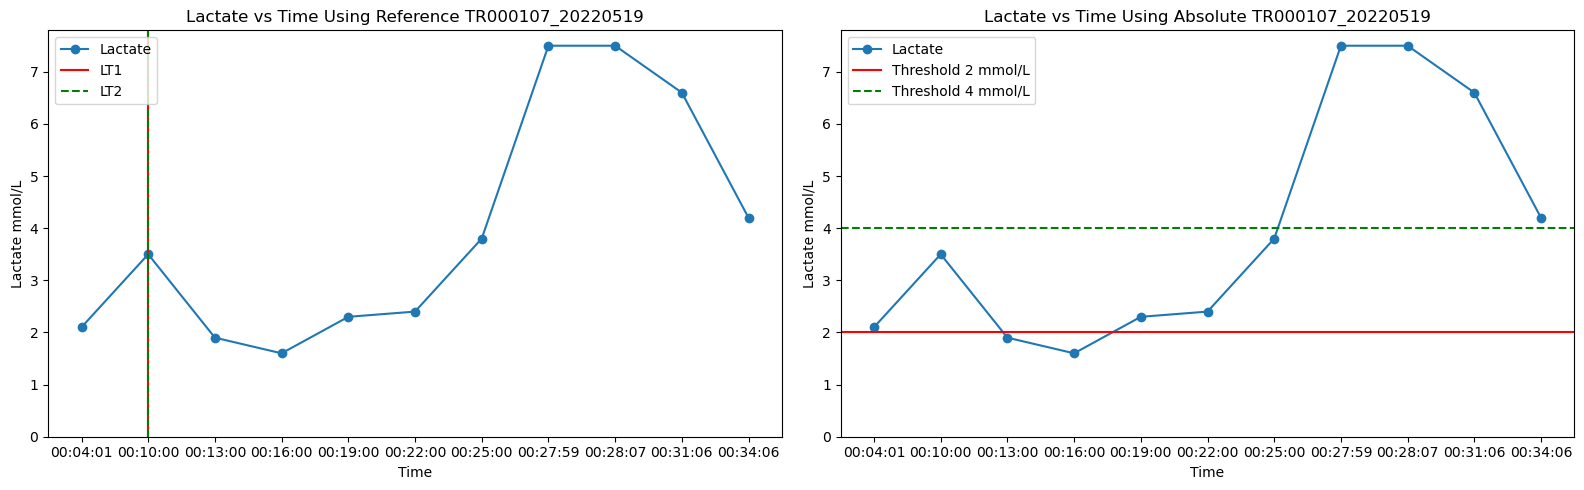

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


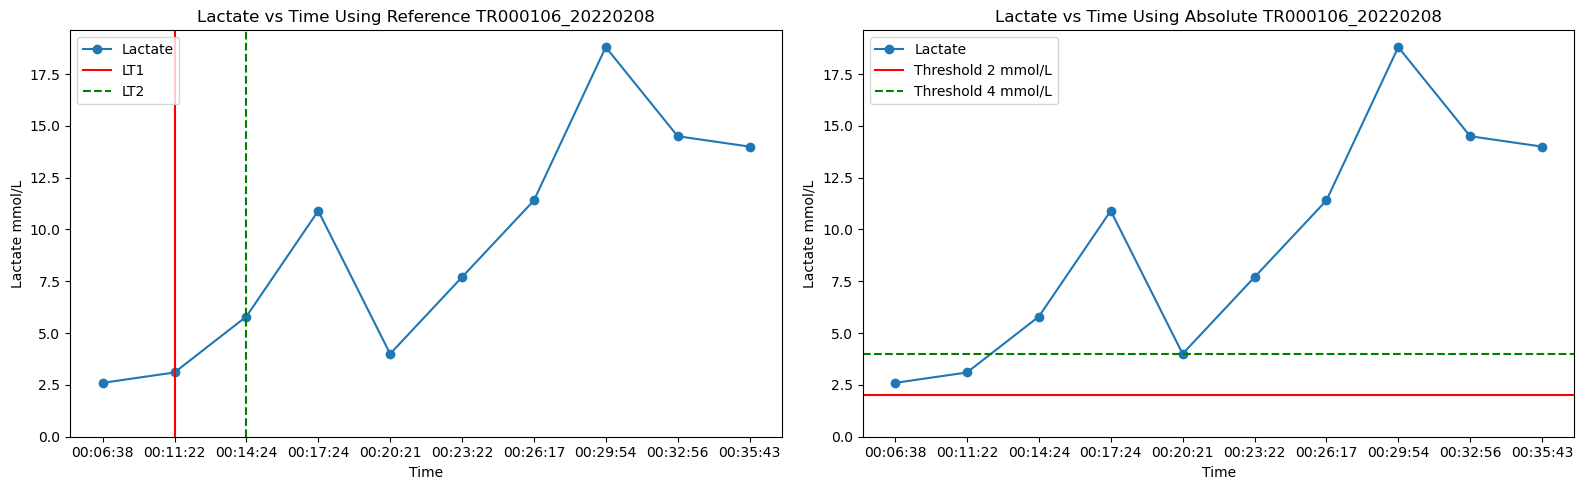

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


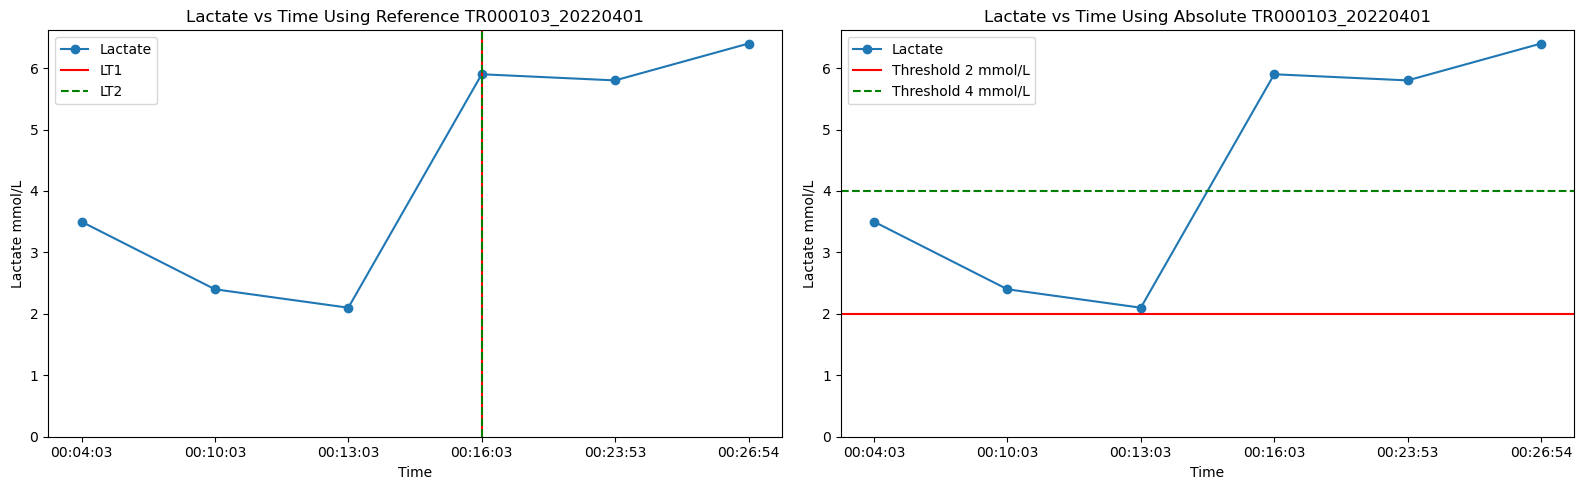

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


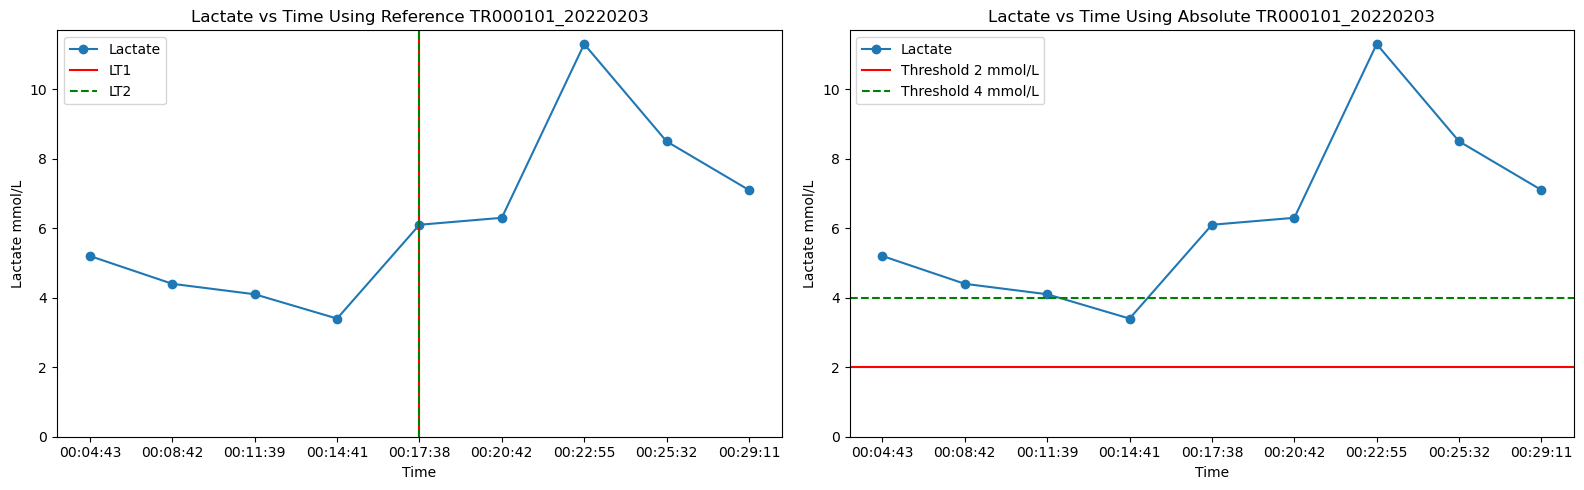

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


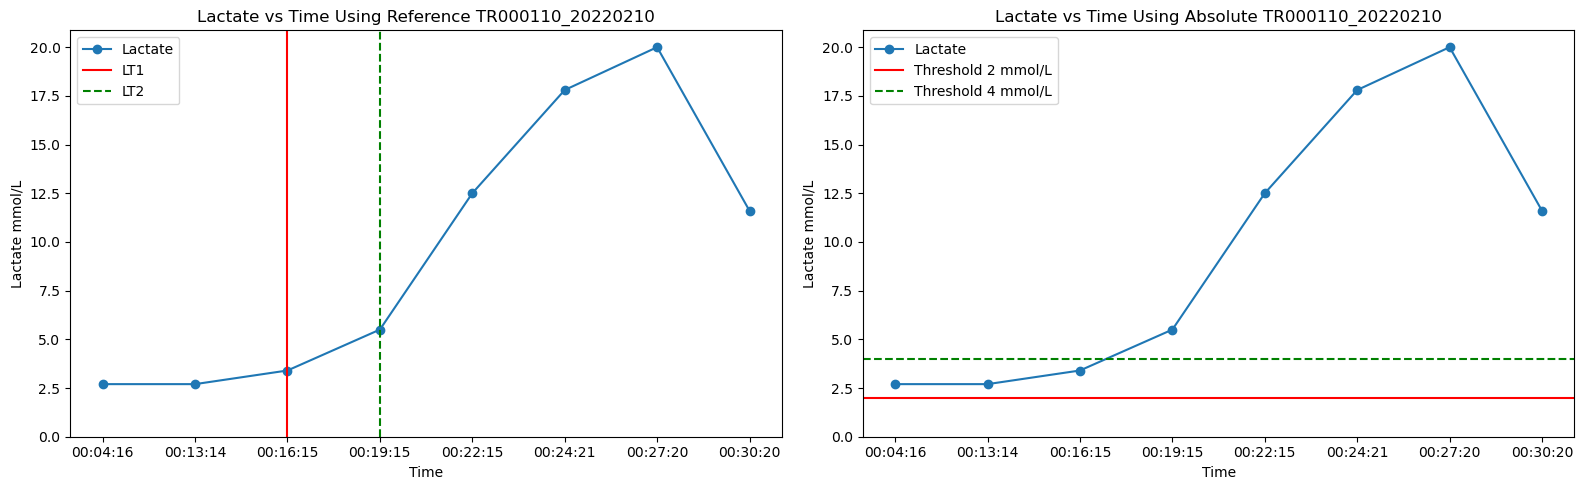

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


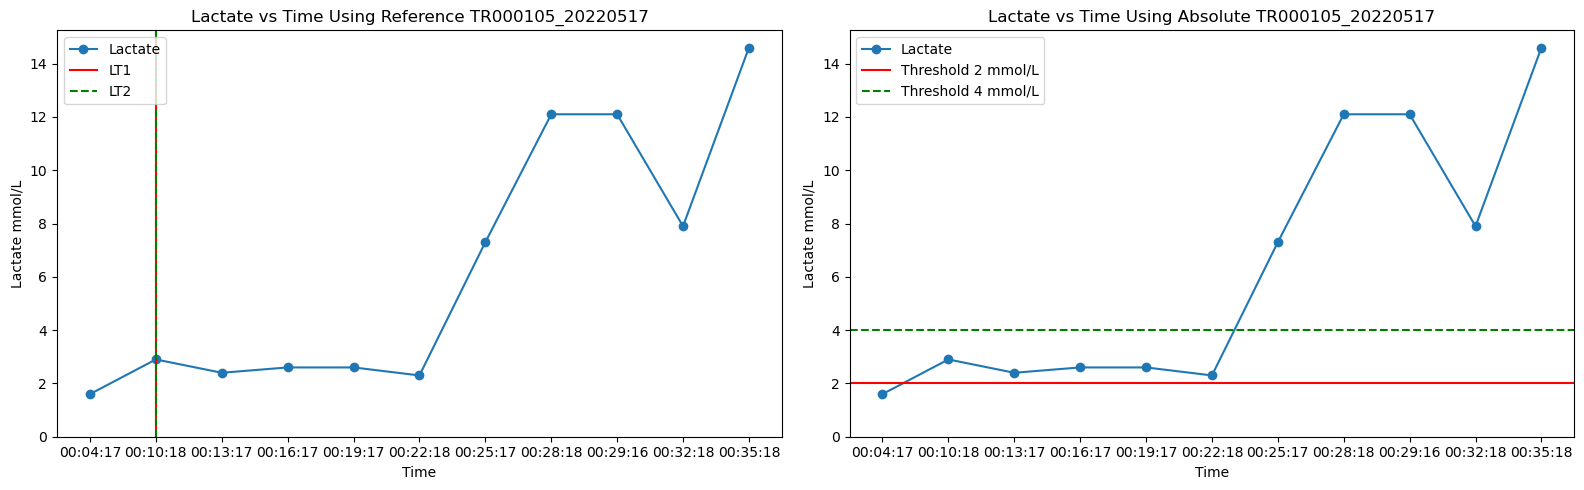

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


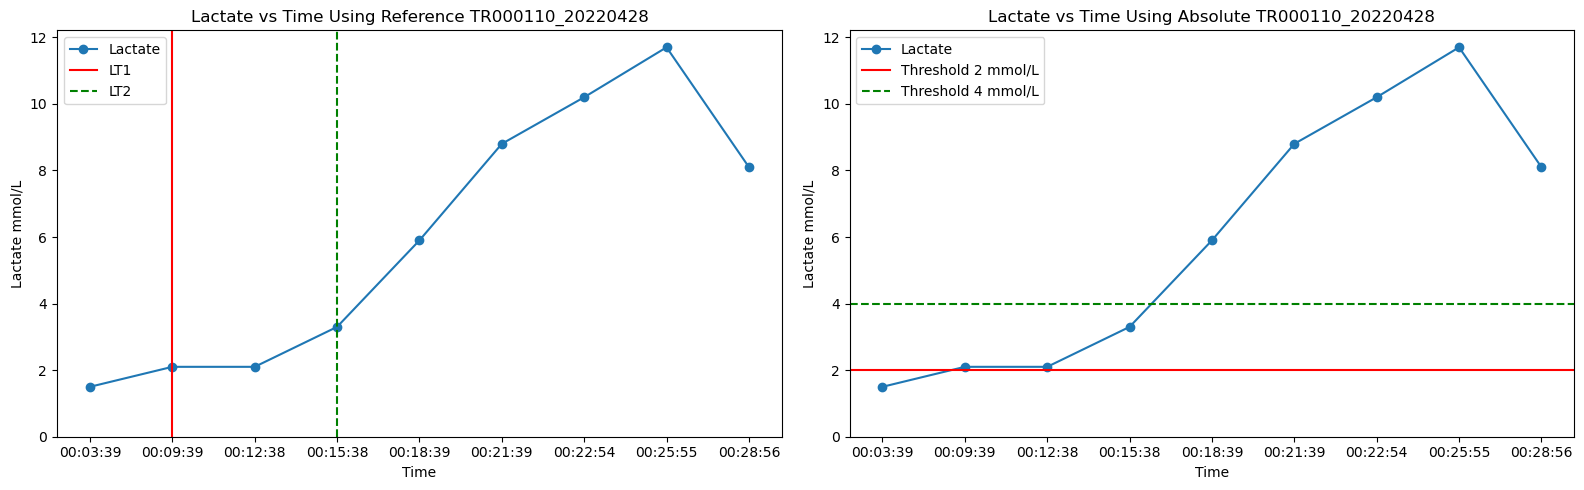

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


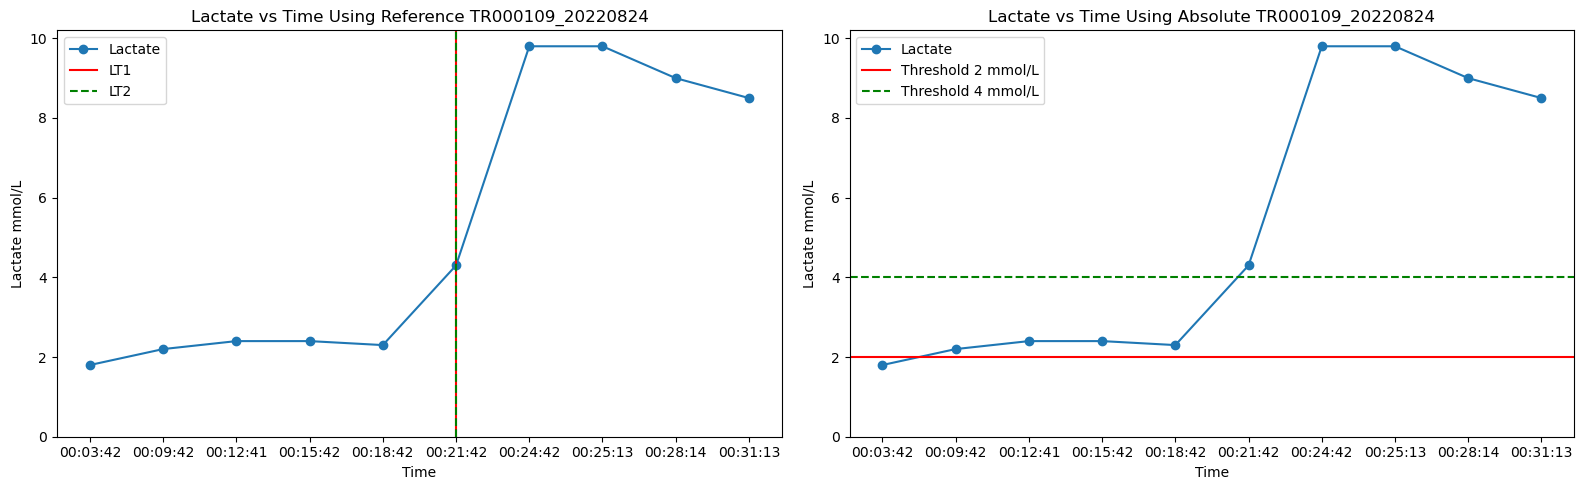

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


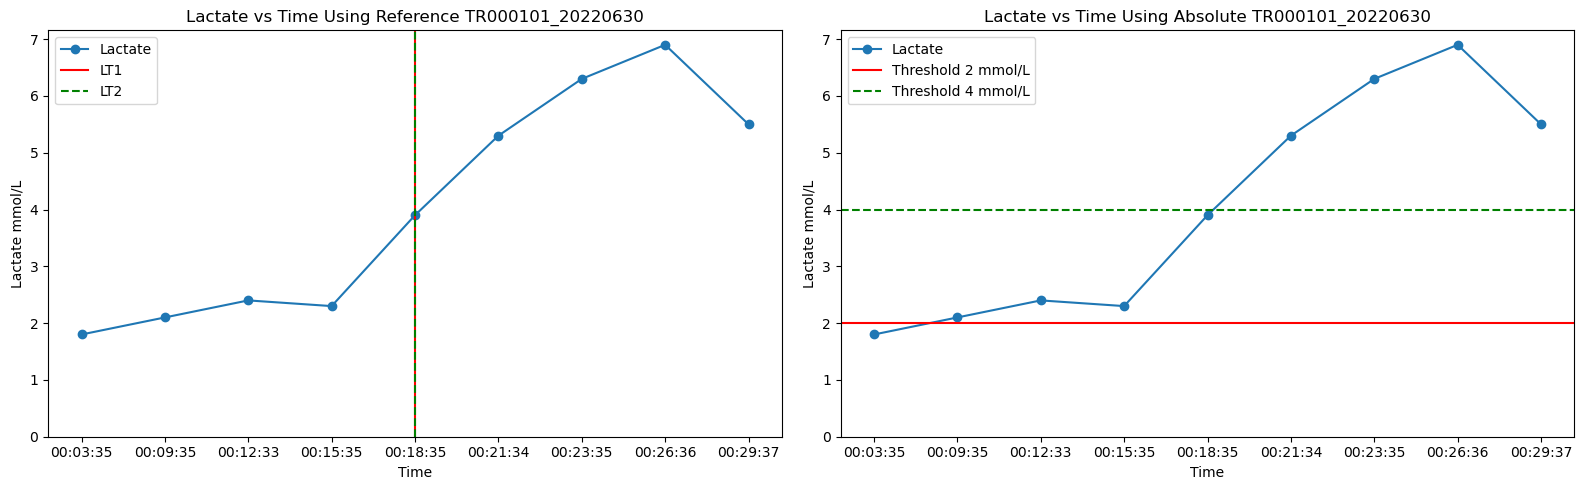

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


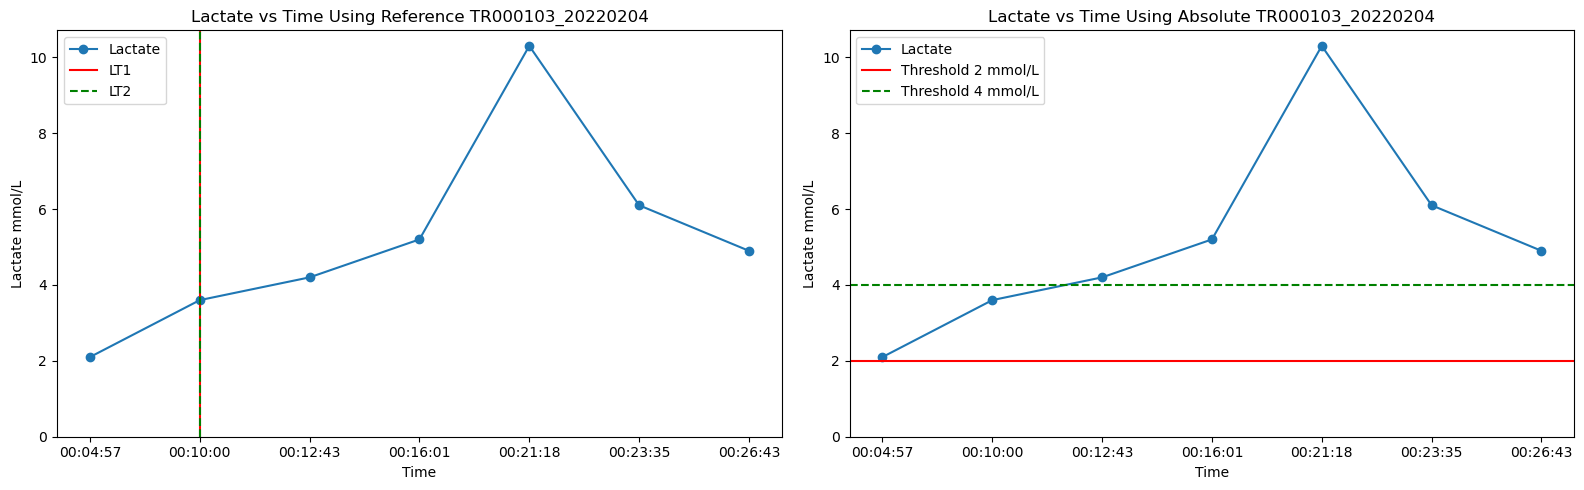

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


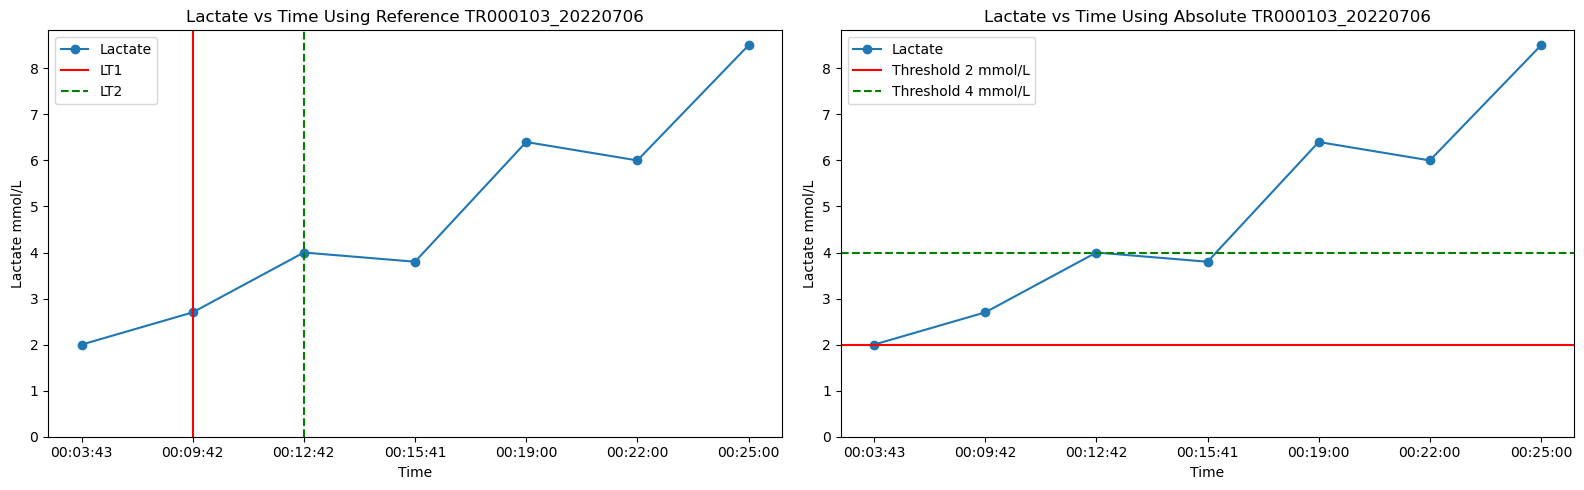

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


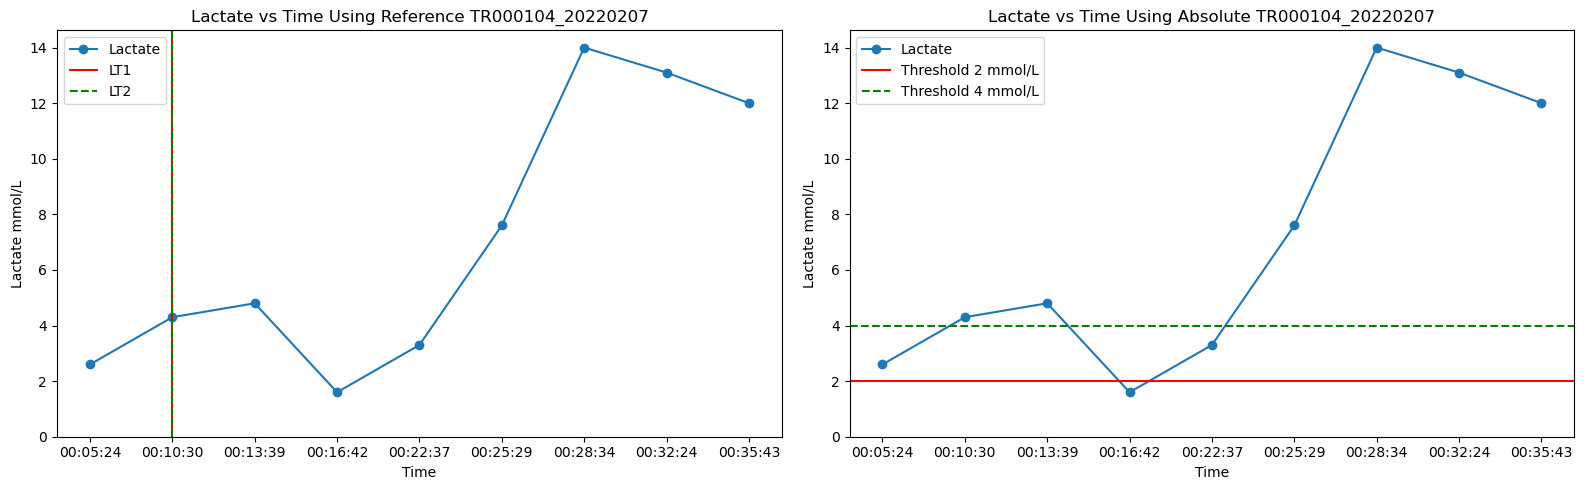

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


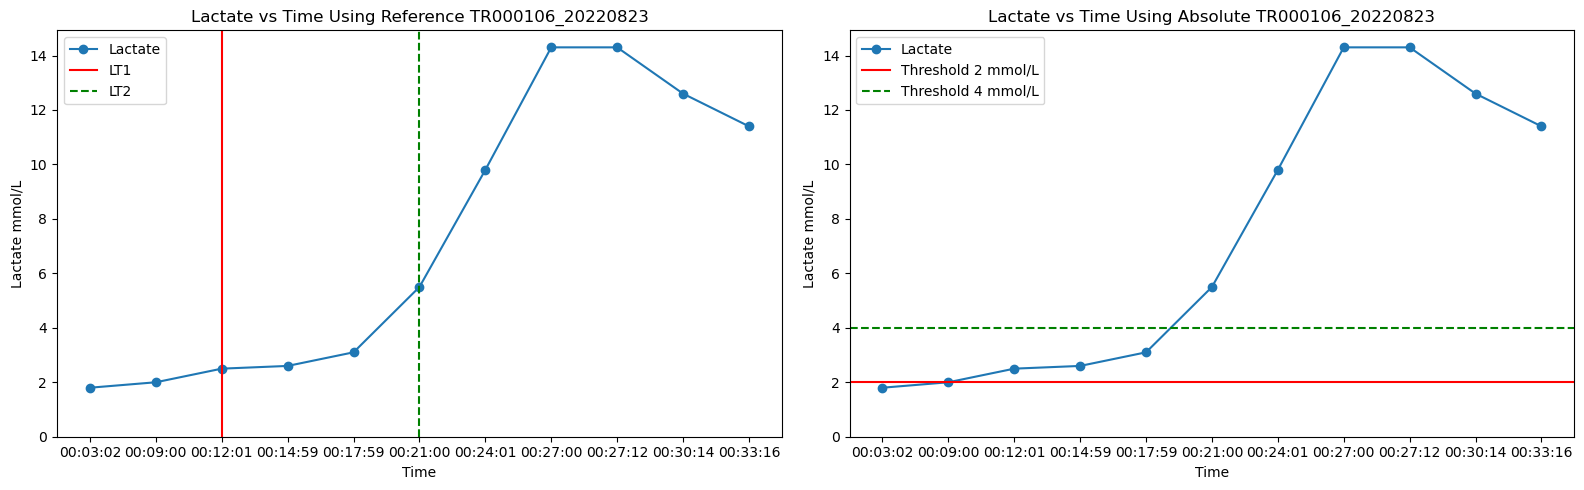

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


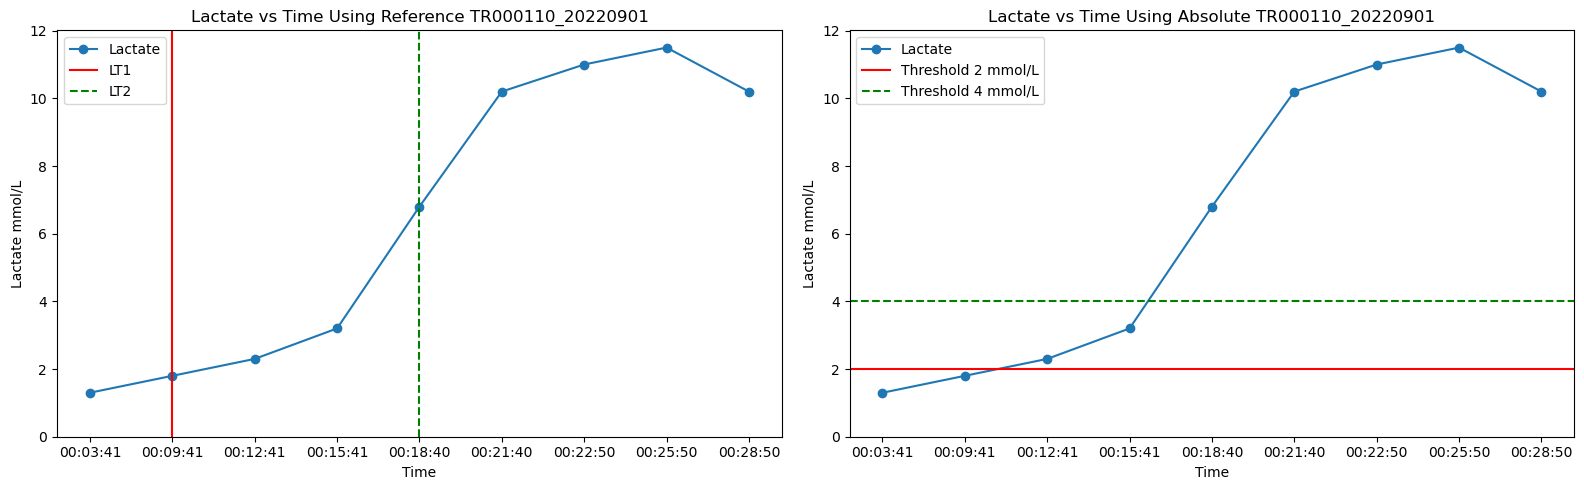

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


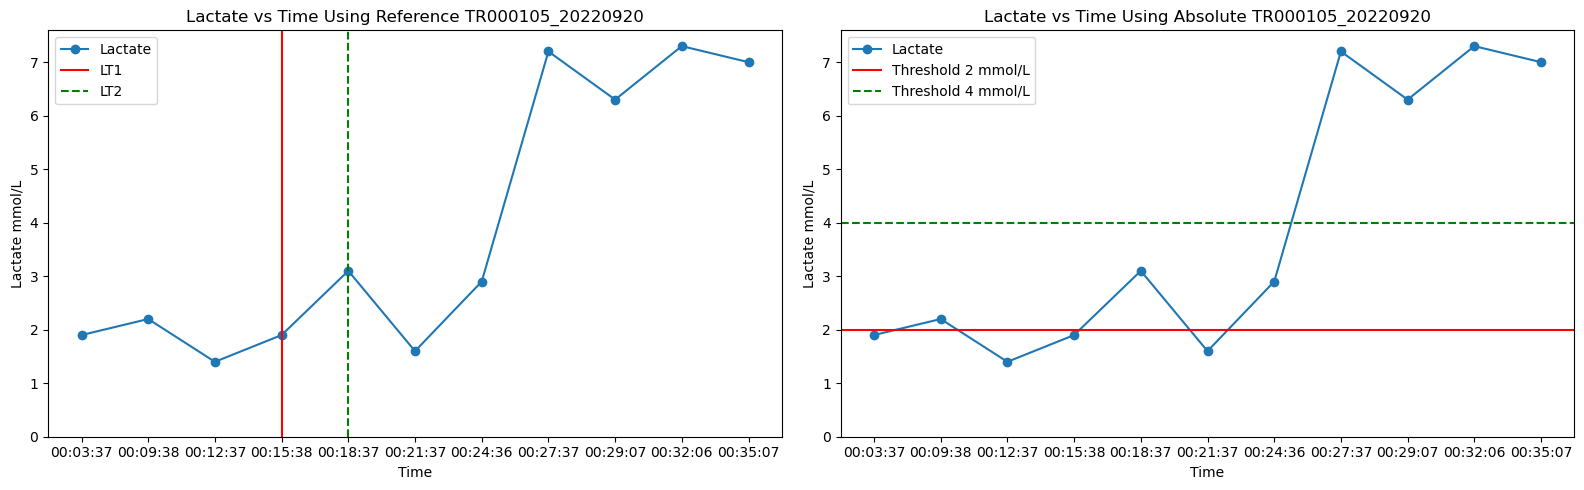

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


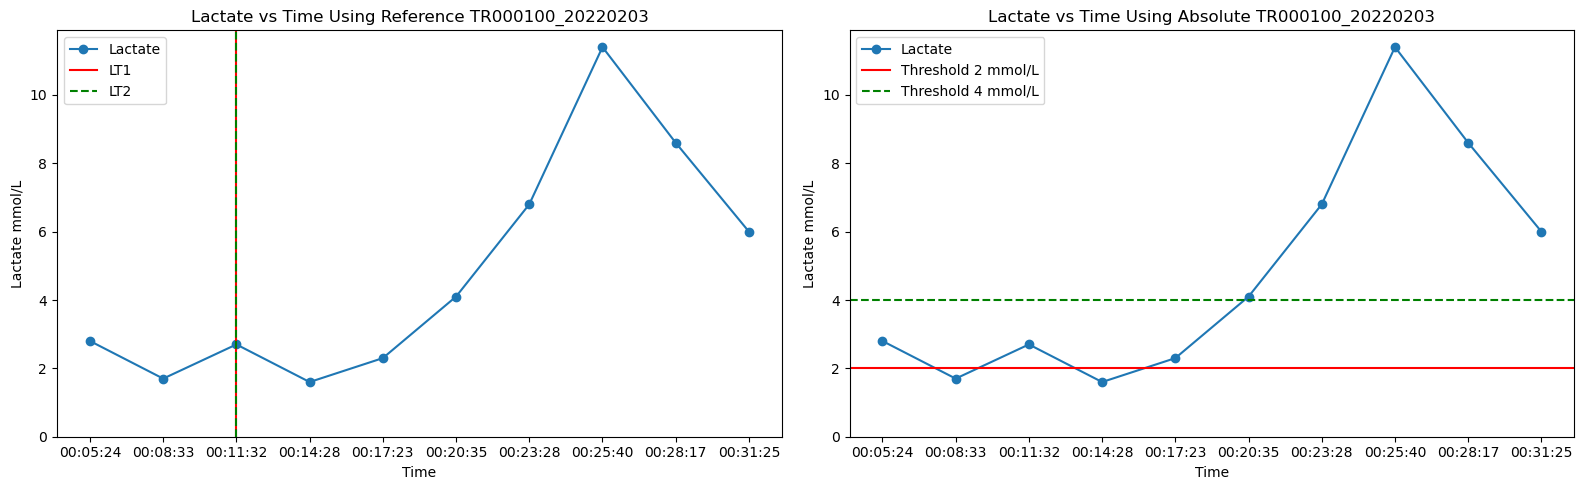

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


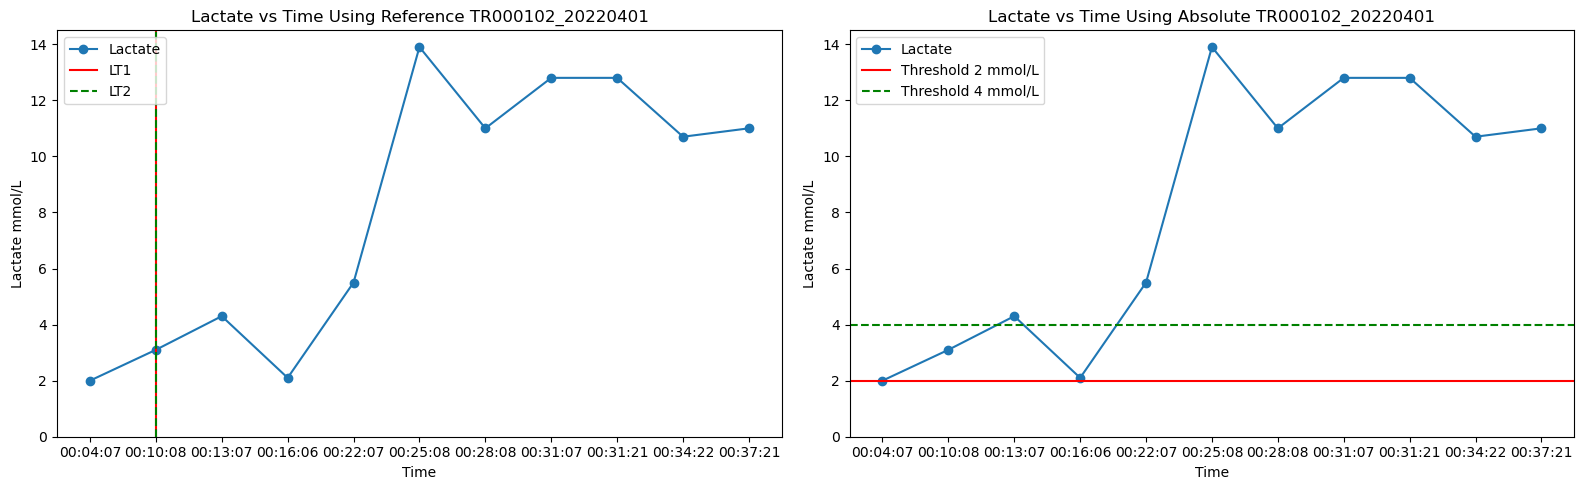

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


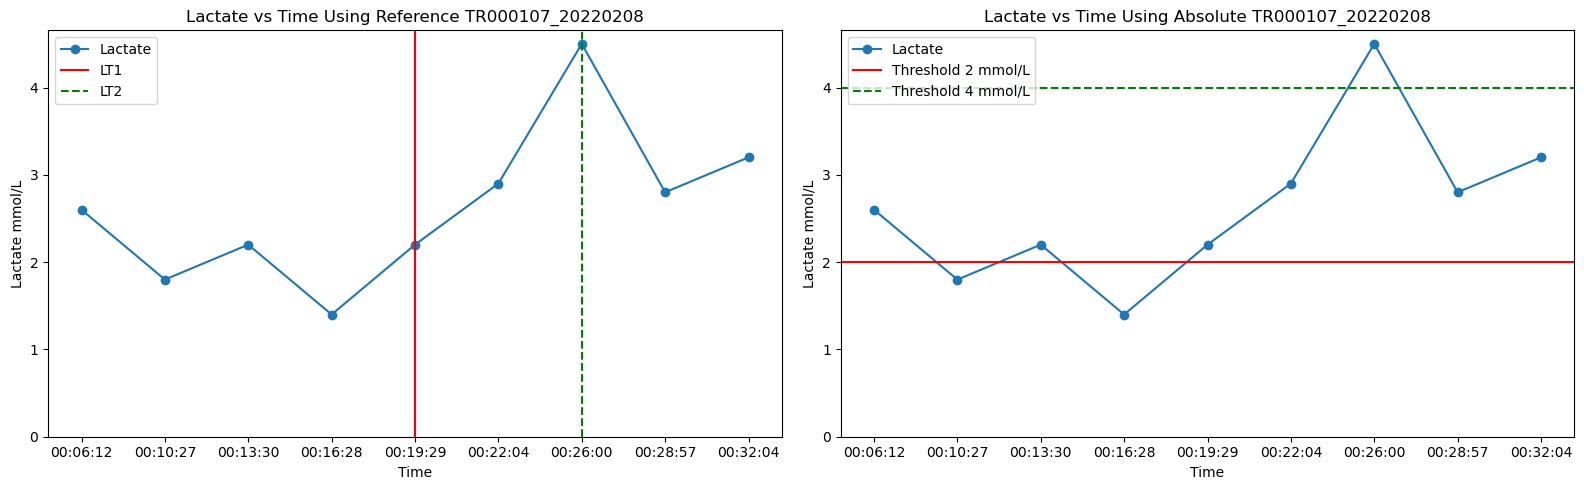

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


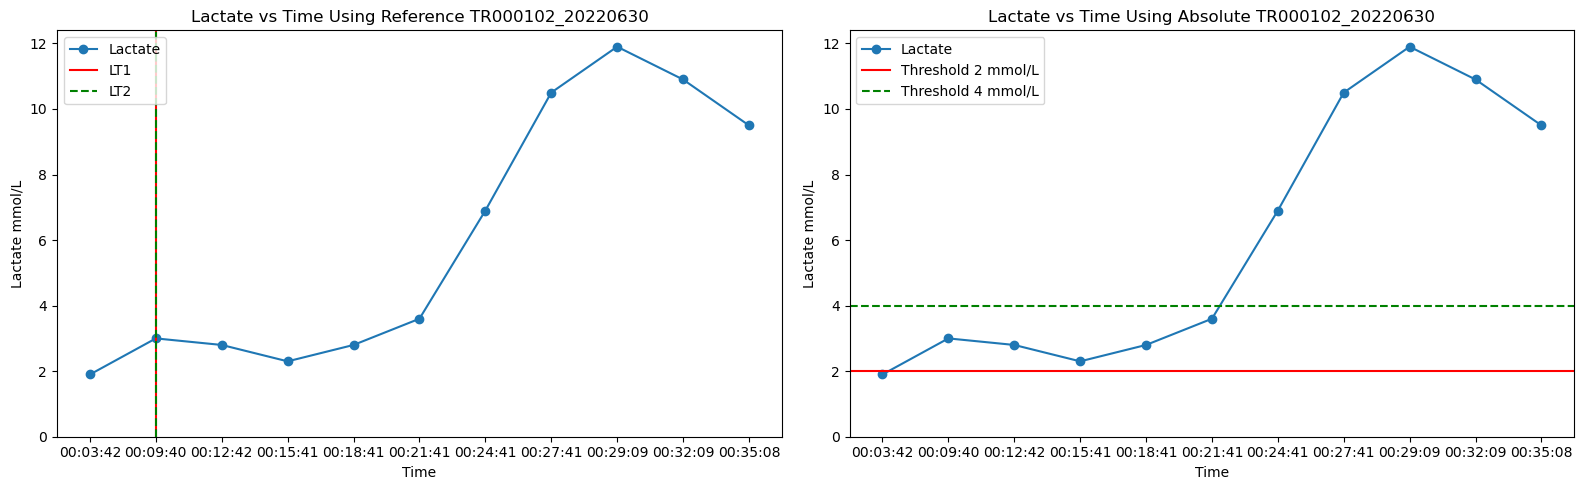

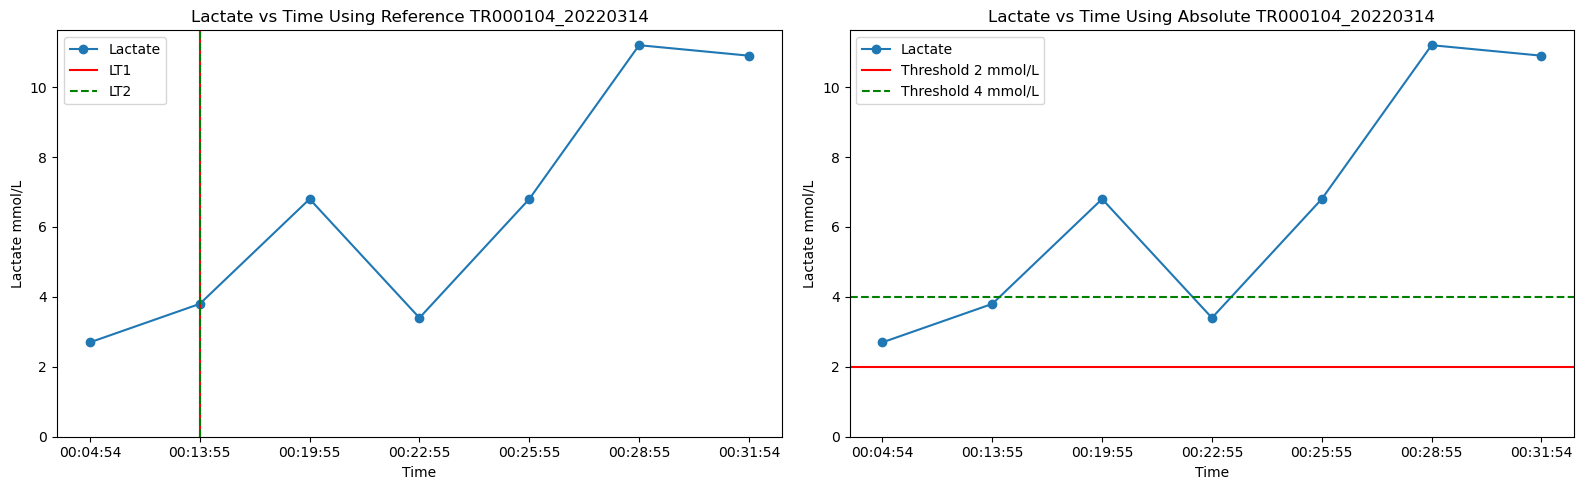

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


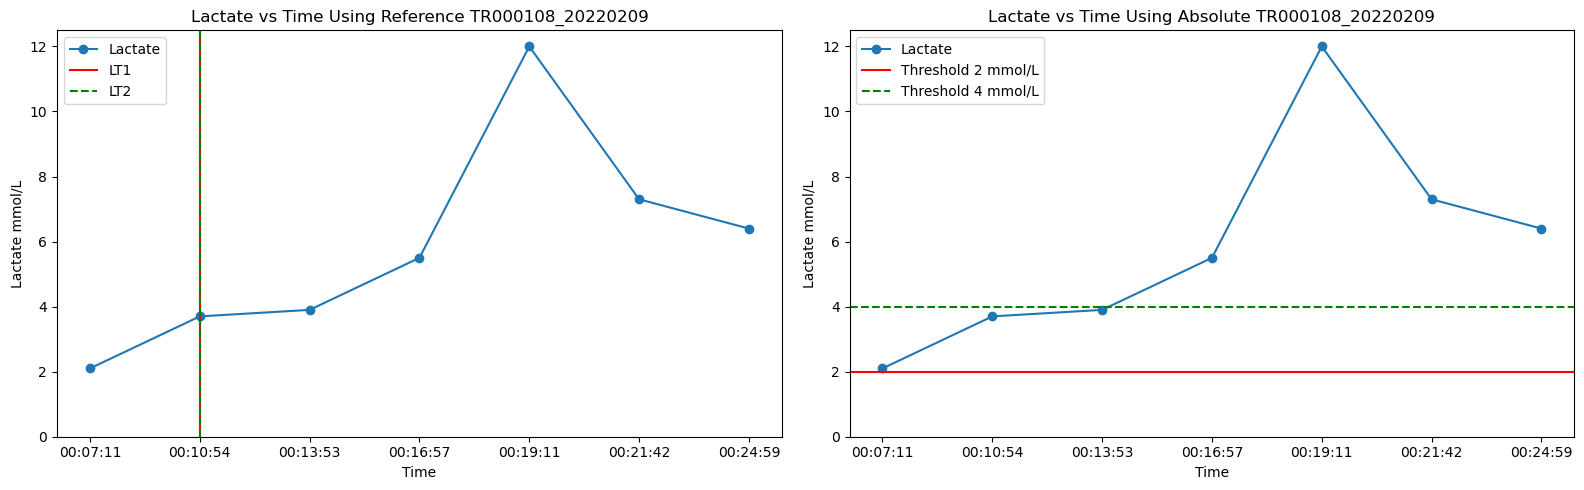

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


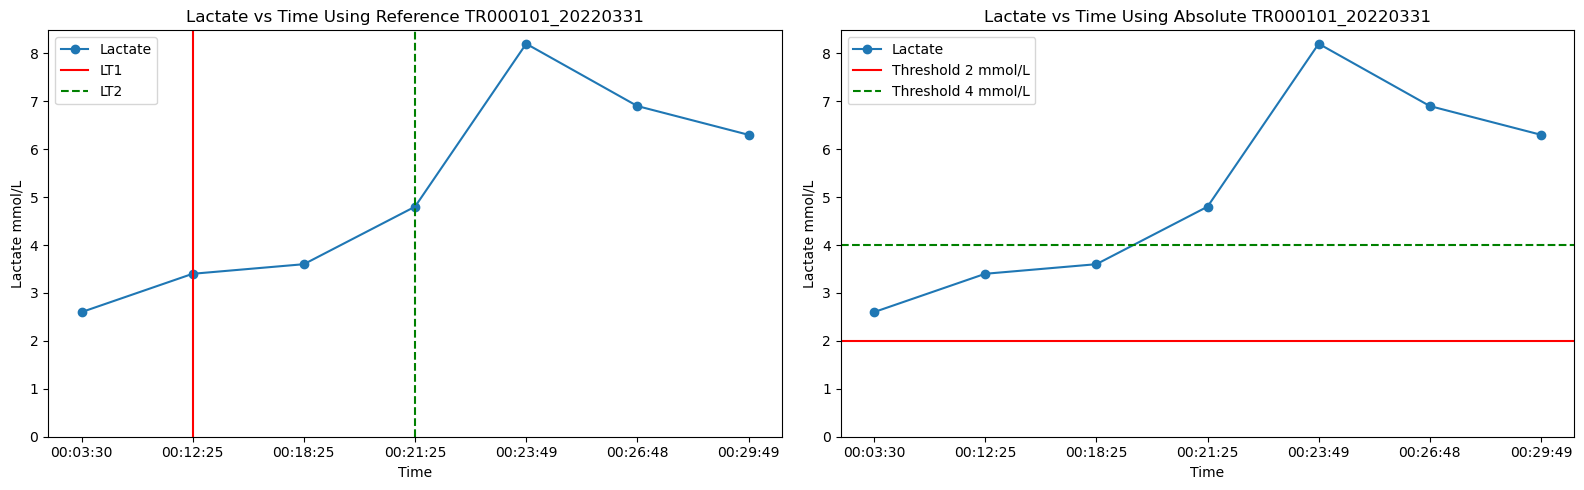

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


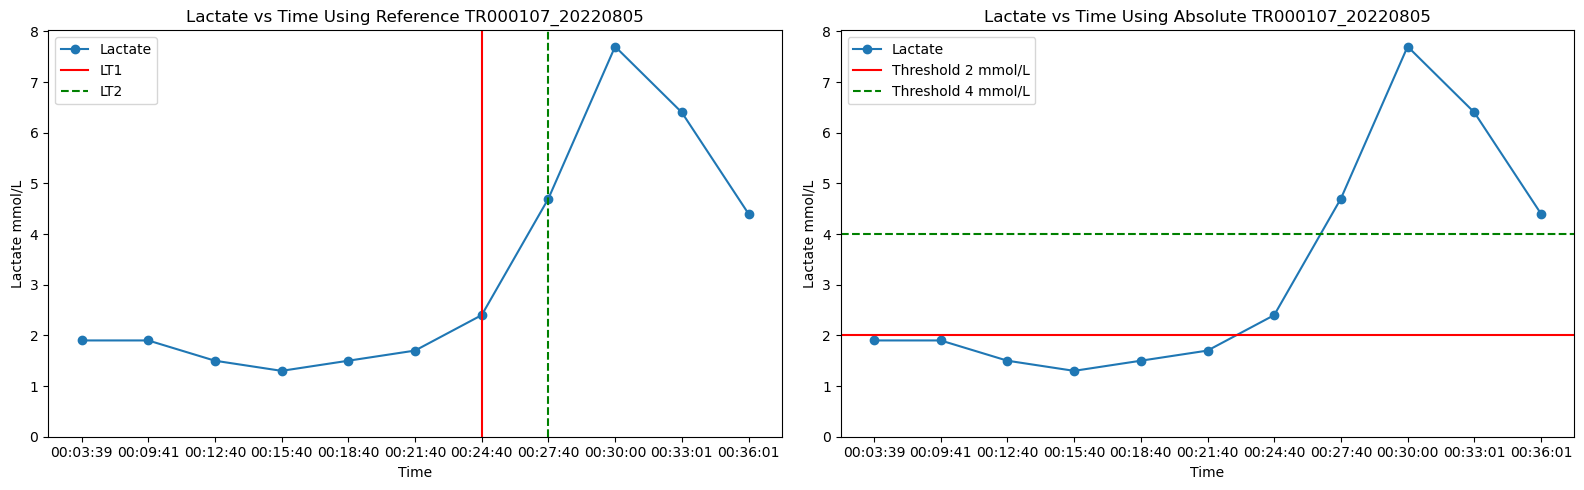

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


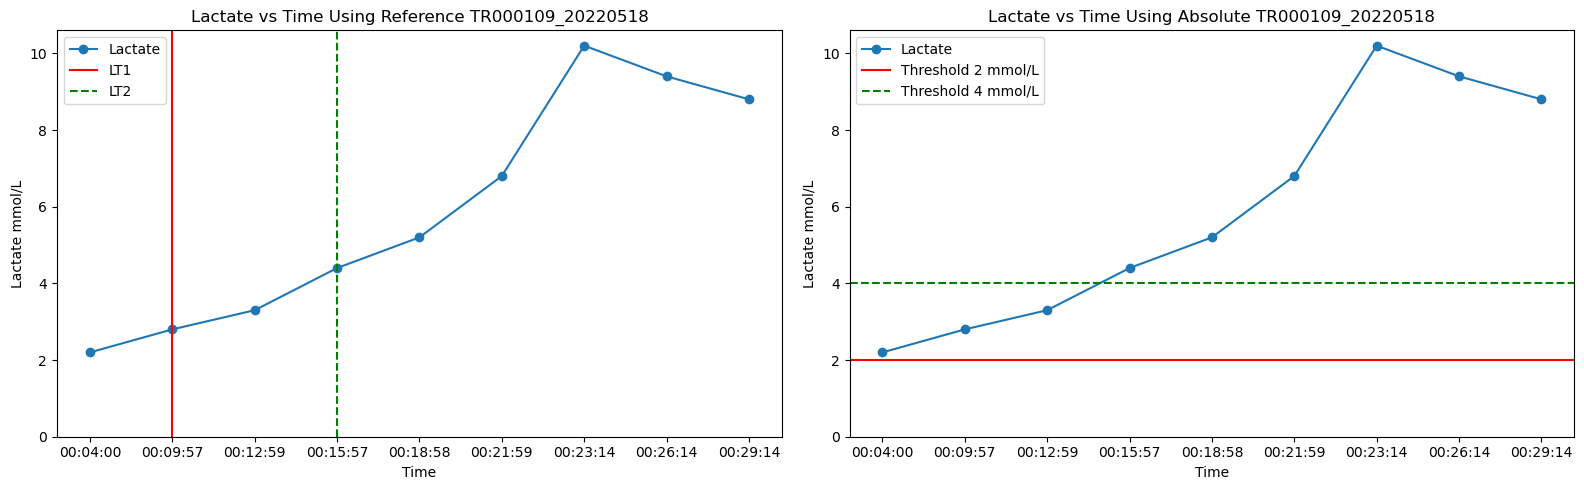

,LT1_Lactate_Ref,LT1_Speed_Ref,LT1_Grade_Ref,LT2_Lactate_Ref,LT2_Speed_Ref,LT2_Grade_Ref,LT1_Lactate_Abs,LT1_Speed_Abs,LT1_Grade_Abs,LT2_Lactate_Abs,LT2_Speed_Abs,LT2_Grade_Abs
Test Name,,,,,,,,,,,,
TR000105_20220207,3.6,4.8,0.0,3.6,4.8,0.0,2.1,2.0,0.0,4.7,6.0,0.0
TR000106_20220420,2.4,7.1,0.0,4.3,8.3,0.0,2.4,7.1,0.0,4.3,8.3,0.0
TR000102_20220204,4.2,6.8,0.0,4.2,6.8,0.0,3.2,2.0,0.0,4.2,6.8,0.0
TR000100_20220623,2.5,8.6,0.0,5.0,9.8,2.0,2.9,2.0,0.0,5.0,9.8,2.0
TR000104_20220627,3.2,8.8,2.0,10.4,8.8,4.0,2.6,2.0,0.0,10.4,8.8,4.0
TR000100_20220331,2.1,9.2,0.0,3.5,9.8,0.0,2.1,2.0,0.0,4.1,2.0,0.0
TR000109_20220209,4.1,6.9,0.0,4.1,6.9,0.0,3.1,2.0,0.0,4.1,6.9,0.0
TR000107_20220519,3.5,8.0,0.0,3.5,8.0,0.0,2.1,2.0,0.0,7.5,10.5,4.0
TR000106_20220208,3.1,5.8,0.0,5.8,6.5,0.0,2.6,2.0,0.0,5.8,6.5,0.0


In [159]:
path = r'visit_data'
filenames = glob.glob(os.path.join(path, "*.csv"))

results = []

for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    test_name = test.name  # Assuming each test has a unique name

    test_results = test.lactate_graph()  # Get structured results
    test_results['Test Name'] = test_name  # Add test name for indexing
    results.append(test_results)

# Convert results into a DataFrame
results_df = pd.DataFrame(results).set_index('Test Name')

results_df